In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymannkendall as mk

In [17]:
def compute_cluster_intensity(df, hazard, cluster_col="yearly_cluster",
                              intensity_stat="mean"):
    intensity_col = hazard_intensity_col[hazard]

    if intensity_stat == "mean":
        agg_fun = "mean"
    elif intensity_stat == "median":
        agg_fun = "median"
    elif intensity_stat == "max":
        agg_fun = "max"
    else:
        raise ValueError("Unsupported intensity_stat")

    cluster_intensity = (
        df.groupby(cluster_col)[intensity_col]
          .agg(agg_fun)
          .reset_index(name="intensity")
    )

    cluster_year = (
        df.groupby(cluster_col)["year"]
          .min()
          .reset_index()
    )

    return cluster_intensity.merge(cluster_year, on=cluster_col)

def yearly_intensity_series(cluster_df):
    return (
        cluster_df
        .groupby("year")["intensity"]
        .mean()   # or median / max depending on interpretation
        .reset_index(name="yearly_intensity")
    )

def bootstrap_sen_CI(values, B=2000, ci=95):
    n = len(values)
    slopes = []

    x = np.arange(n)

    for _ in range(B):
        idx = np.random.randint(0, n, n)
        y_sample = values[idx]
        x_sample = x[idx]

        # reorder in time
        order = np.argsort(x_sample)
        y_sorted = y_sample[order]

        try:
            res = mk.original_test(y_sorted)
            slopes.append(res.slope)
        except:
            continue
    
    lower = np.percentile(slopes, (100-ci)/2)
    upper = np.percentile(slopes, 100 - (100-ci)/2)

    return lower, upper

def add_missing_years_zero(df, year_col="year", value_col="total_cells",
                           start_year=1991, end_year=2070):
    df = df.copy()

    # Keep only desired range
    df = df[(df[year_col] >= start_year) & (df[year_col] <= end_year)]

    # Set index to year
    df = df.set_index(year_col)

    # Full year index
    full_years = pd.Index(np.arange(start_year, end_year + 1), name=year_col)

    # Reindex and fill missing with 0
    df_full = df.reindex(full_years, fill_value=0).reset_index()

    return df_full

In [19]:
def plot_yearly_with_MK_CI_var2(
    yearly_df,
    label,
    color="steelblue",
    alpha_acf_trigger=0.2,
    use_log_if_positive=False,
    ci_method="bootstrap",
    aggregation_type="yearly_intensity",
    characteristic='intensity'
):
    """
    Plot yearly series with Mann–Kendall trend test + Sen's slope + 95% CI.

    Enhancements vs original:
      - Explicitly reports Kendall's tau (τ)
      - Automatically switches to Hamed–Rao modified MK if lag-1 autocorrelation is notable
      - Optional log-transform (useful for exponential-like growth), only if values are > 0

    Parameters
    ----------
    yearly_df : pandas.DataFrame
        Must contain columns: 'date' and 'count'
    label : str
        Title/label for plot and console summary
    color : str
        Line color for raw series
    alpha_acf_trigger : float
        Absolute lag-1 autocorrelation threshold to trigger Hamed–Rao MK (default 0.2)
    use_log_if_positive : bool
        If True, run MK/Sen on log(count). This is often better for exponential trends.
    ci_method : str
        Currently only "bootstrap" is expected (calls bootstrap_sen_CI(values_used)).

    Notes
    -----
    - Requires:
        * `import pymannkendall as mk` somewhere in your environment
        * a function `bootstrap_sen_CI(values)` returning (lower_slope, upper_slope)
    """

    # ----------------------------
    # 0) Extract data
    # ----------------------------
    dates = yearly_df["year"].values
    values = yearly_df[aggregation_type].astype(float).values

    # ----------------------------
    # 1) Optional log transform
    # ----------------------------
    values_used = values.copy()
    scale_note = "raw"
    if use_log_if_positive:
        if np.any(values_used <= 0):
            raise ValueError("use_log_if_positive=True requires all values > 0.")
        values_used = np.log(values_used)
        scale_note = "log"

    # ----------------------------
    # 2) Lag-1 autocorrelation (simple, robust)
    # ----------------------------
    def _lag1_autocorr(y):
        y = np.asarray(y)
        if len(y) < 3:
            return np.nan
        y0, y1 = y[:-1], y[1:]
        # guard against constant series
        if np.std(y0) == 0 or np.std(y1) == 0:
            return 0.0
        return np.corrcoef(y0, y1)[0, 1]

    acf1 = _lag1_autocorr(values_used)

    # ----------------------------
    # 3) Mann–Kendall test (auto-switch)
    # ----------------------------
    # Choose MK variant based on autocorrelation
    if np.isfinite(acf1) and abs(acf1) >= alpha_acf_trigger:
        mk_res = mk.hamed_rao_modification_test(values_used)
        mk_method = f"Hamed–Rao (acf1={acf1:.2f})"
    else:
        mk_res = mk.original_test(values_used)
        mk_method = f"Original (acf1={acf1:.2f})"

    slope = mk_res.slope
    pval = mk_res.p
    tau = mk_res.Tau

    # ----------------------------
    # 4) Significance text
    # ----------------------------
    if pval < 0.001:
        signif = "***"
        ptext = "p < 0.001"
    elif pval < 0.01:
        signif = "**"
        ptext = f"p = {pval:.3f}"
    elif pval < 0.05:
        signif = "*"
        ptext = f"p = {pval:.3f}"
    else:
        signif = "ns"
        ptext = f"p = {pval:.3f}"

    direction = "increasing" if slope > 0 else "decreasing" if slope < 0 else "no trend"

    # ----------------------------
    # 5) Sen trend line (same scale as test)
    # ----------------------------
    x = np.arange(len(values_used))
    intercept = np.median(values_used - slope * x)
    trend_line = intercept + slope * x

    # ----------------------------
    # 6) 95% CI for Sen slope (bootstrap)
    # ----------------------------
    if ci_method.lower() != "bootstrap":
        raise ValueError("Only ci_method='bootstrap' is currently supported in this function.")

    lower_slope, upper_slope = bootstrap_sen_CI(values_used)
    trend_lower = intercept + lower_slope * x
    trend_upper = intercept + upper_slope * x
    ci_excludes_zero = not (lower_slope < 0 < upper_slope)

    # ----------------------------
    # 7) If log-scale, map lines back to original units for plotting
    # ----------------------------
    plot_values = values
    plot_trend = trend_line
    plot_lower = trend_lower
    plot_upper = trend_upper

    slope_for_label = slope
    ci_for_label = (lower_slope, upper_slope)

    if scale_note == "log":
        # Back-transform for plotting
        plot_trend = np.exp(trend_line)
        plot_lower = np.exp(trend_lower)
        plot_upper = np.exp(trend_upper)

        # Express slope as approx %/year for readability:
        # growth_rate ≈ (exp(beta)-1)*100 where beta is slope on log scale
        slope_for_label = (np.exp(slope) - 1.0) * 100.0
        ci_for_label = ((np.exp(lower_slope) - 1.0) * 100.0, (np.exp(upper_slope) - 1.0) * 100.0)

    # ----------------------------
    # 8) Plot
    # ----------------------------
    plt.figure(figsize=(12, 5))

    plt.plot(dates, plot_values, "-o", color=color, alpha=0.9, label="Yearly totals")

    if scale_note == "raw":
        slope_label = f"{slope_for_label:.3f} events/year"
        ci_label = f"[{ci_for_label[0]:.3f}, {ci_for_label[1]:.3f}]"
    else:
        slope_label = f"{slope_for_label:.2f}%/year"
        ci_label = f"[{ci_for_label[0]:.2f}, {ci_for_label[1]:.2f}]"

    plt.plot(
        dates, plot_trend, "--", color="black", linewidth=2,
        label=(f"Sen: {slope_label}, τ={tau:.2f} ({direction}; {ptext}; {mk_method})")
    )

    plt.fill_between(
        dates, plot_lower, plot_upper,
        color="gray", alpha=0.25, label=f"95% CI ({ci_method}; {ci_label})"
    )

    plt.title(f"{label}\nMann–Kendall Trend with Sen’s Slope (Yearly)", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Yearly event " + characteristic, fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # 9) Console summary
    # ----------------------------
    print(f"\n=== {label} Yearly Trend Summary ===")
    print(f"MK method: {mk_method}")
    print(f"Scale used for test: {scale_note}")
    print(f"Kendall’s tau (τ): {tau:.4f}")
    if scale_note == "raw":
        print(f"Sen slope: {slope:.4f} events/year ({direction})")
        print(f"Bootstrap CI (slope): [{lower_slope:.4f}, {upper_slope:.4f}]")
    else:
        print(f"Sen slope (log-scale): {slope:.6f} 1/year ({direction})")
        print(f"Approx growth rate: {(np.exp(slope)-1)*100:.3f}%/year")
        print(f"Bootstrap CI (growth rate): [{ci_for_label[0]:.3f}, {ci_for_label[1]:.3f}] %/year")
    print(f"Mann–Kendall: {ptext} (significance: {signif})")
    print(f"CI excludes zero: {ci_excludes_zero}\n")

    # Return results in case you want to save them
    return {
        "mk_method": mk_method,
        "scale": scale_note,
        "tau": tau,
        "p": pval,
        "slope_raw": slope if scale_note == "raw" else None,
        "slope_log": slope if scale_note == "log" else None,
        "slope_ci": (lower_slope, upper_slope),
        "acf1": acf1,
    }
#Multi-hazard combo plotting
def plot_mh_trends_mk_rao_bootstrap(df_name,hazard_1,hazard_2,hazard_combo,time1,time2,title_name,color_choice):
    df=pd.read_csv('OUTPUT/'+df_name) #df_name is the full multi-hazard file e.g., consecutive_tl3_85_full.csv
    df_sel=df[df[hazard_combo].notna()] #hazard combo is the short name of the combo you want to plot e.g., drought-heat -> this is the column over which we search for non nans elements in the full dataset
    df_sel['time'] = pd.to_datetime(df['time'], format="mixed", errors="raise").dt.normalize() #time and date can be non-consistent due to orignal modelling data savings
    df_sel=df_sel[['time','lon','lat',hazard_1+'_clusters',hazard_2+'_clusters',hazard_combo]] #skip other columns
    df_sel['year']=pd.to_datetime(df_sel['time']).dt.year #create year column
    df_yearly=df_sel.groupby(['year']).size().reset_index(name='total_cells') #change this if you want to change the parameter to calculate. This works for total cells
    #print(df_yearly)
    df_full = add_missing_years_zero(df_yearly,start_year=time1,end_year=time2) #add zeros if some years are missing completely!
    #print(df_full)
    outcome=plot_yearly_with_MK_CI_var2(df_full, title_name+" total cells", color=color_choice,aggregation_type="total_cells",characteristic='Total cells')# applies previous function for MK trends
    return(outcome)

## Single hazard trends- an example for intensity

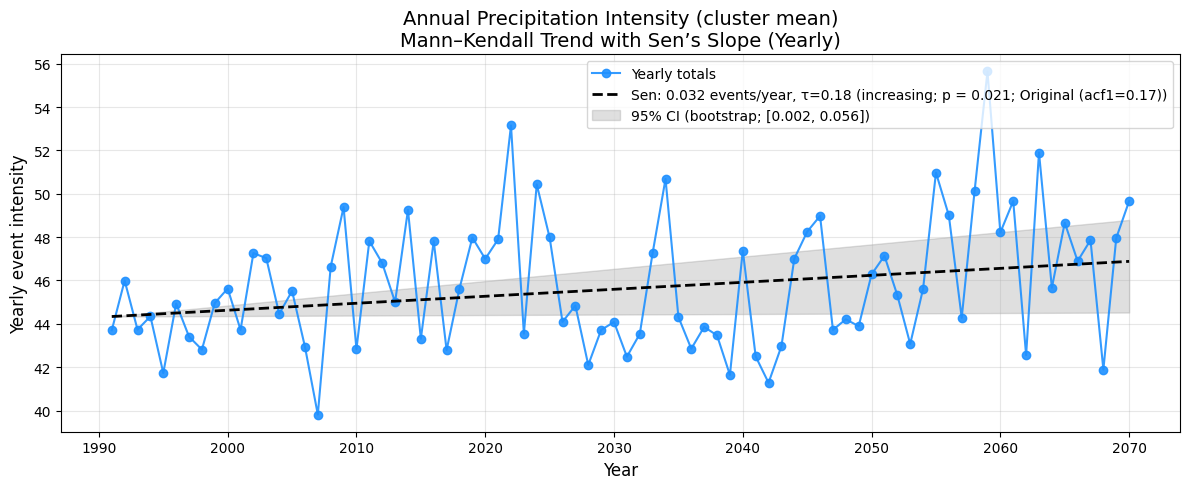


=== Annual Precipitation Intensity (cluster mean) Yearly Trend Summary ===
MK method: Original (acf1=0.17)
Scale used for test: raw
Kendall’s tau (τ): 0.1759
Sen slope: 0.0322 events/year (increasing)
Bootstrap CI (slope): [0.0023, 0.0564]
Mann–Kendall: p = 0.021 (significance: *)
CI excludes zero: True



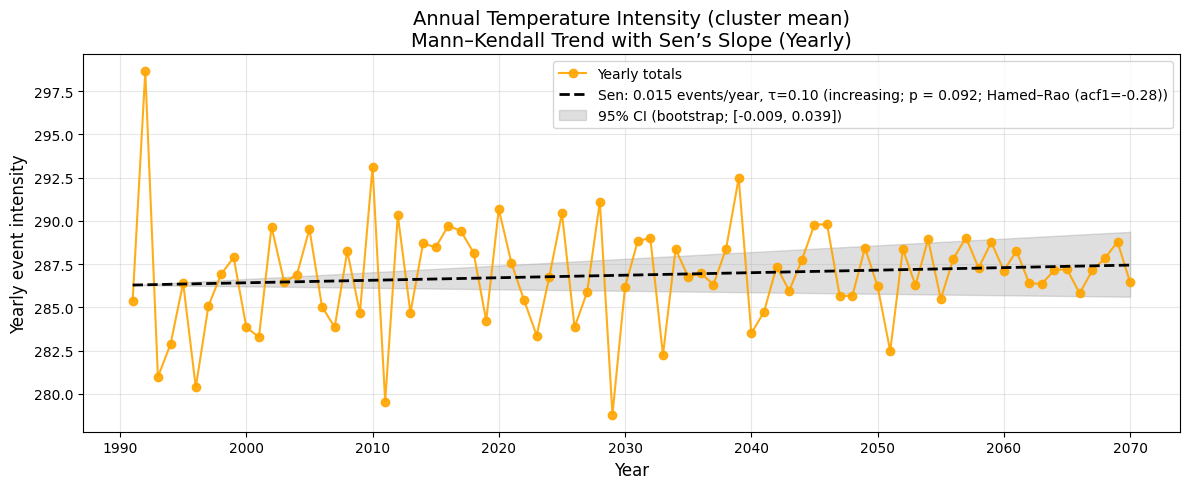


=== Annual Temperature Intensity (cluster mean) Yearly Trend Summary ===
MK method: Hamed–Rao (acf1=-0.28)
Scale used for test: raw
Kendall’s tau (τ): 0.0975
Sen slope: 0.0146 events/year (increasing)
Bootstrap CI (slope): [-0.0086, 0.0389]
Mann–Kendall: p = 0.092 (significance: ns)
CI excludes zero: False



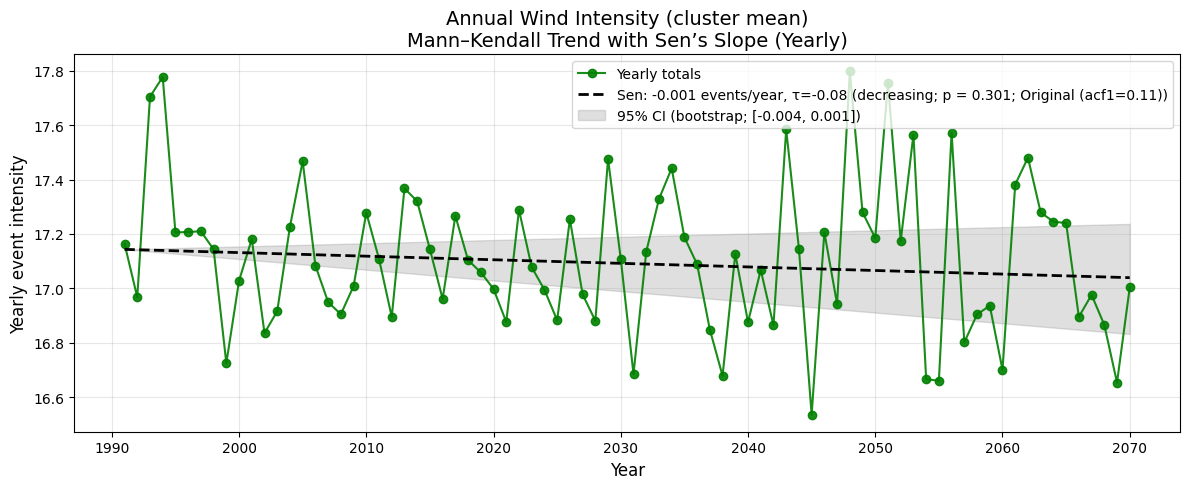


=== Annual Wind Intensity (cluster mean) Yearly Trend Summary ===
MK method: Original (acf1=0.11)
Scale used for test: raw
Kendall’s tau (τ): -0.0791
Sen slope: -0.0013 events/year (decreasing)
Bootstrap CI (slope): [-0.0039, 0.0012]
Mann–Kendall: p = 0.301 (significance: ns)
CI excludes zero: False



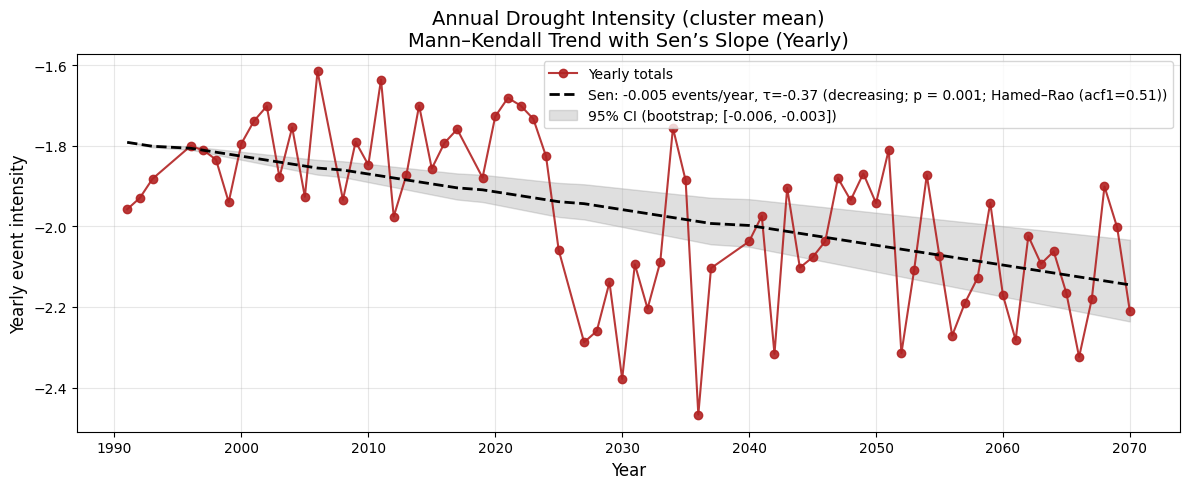


=== Annual Drought Intensity (cluster mean) Yearly Trend Summary ===
MK method: Hamed–Rao (acf1=0.51)
Scale used for test: raw
Kendall’s tau (τ): -0.3691
Sen slope: -0.0049 events/year (decreasing)
Bootstrap CI (slope): [-0.0062, -0.0034]
Mann–Kendall: p = 0.001 (significance: **)
CI excludes zero: True



{'mk_method': 'Hamed–Rao (acf1=0.51)',
 'scale': 'raw',
 'tau': -0.3691019786910198,
 'p': 0.0011118319799359178,
 'slope_raw': -0.004913814343497811,
 'slope_log': None,
 'slope_ci': (-0.006175916553525019, -0.0033587653331436347),
 'acf1': 0.5145637513912631}

In [14]:
#Single hazards
hazard_intensity_col = {
    "drought": "spi_pearson_360",   # SPI-12 daily value
    "prec":    "TOT_PREC",        # daily precipitation total
    "temp":    "T_2M",            # mean daily temperature anomaly
    "wind":    "wind"             # max daily wind speed
}
drought_df=pd.read_csv('OUTPUT/CMCC_PRO_45/drought/15_NO_F_clust_v2.csv')#substitute with the that of the single hazard aggregated data (all the time-period)
prec_df=pd.read_csv('OUTPUT/CMCC_PRO_45/prec/99_YES_F_clust_v2.csv')
wind_df=pd.read_csv('OUTPUT/CMCC_PRO_45/wind/99_YES_F_clust_v2.csv')
temp_df=pd.read_csv('OUTPUT/CMCC_PRO_45/heat/95_YES_F_clust_v2.csv')
# Precip intensity
prec_cluster_int = compute_cluster_intensity(prec_df, "prec", intensity_stat="mean")
yearly_prec_int  = yearly_intensity_series(prec_cluster_int)
plot_yearly_with_MK_CI_var2(yearly_prec_int, "Annual Precipitation Intensity (cluster mean)", color="dodgerblue")

# Temperature intensity
temp_cluster_int = compute_cluster_intensity(temp_df, "temp", intensity_stat="mean")
yearly_temp_int  = yearly_intensity_series(temp_cluster_int)
plot_yearly_with_MK_CI_var2(yearly_temp_int, "Annual Temperature Intensity (cluster mean)", color="orange")

# Wind intensity
wind_cluster_int = compute_cluster_intensity(wind_df, "wind", intensity_stat="mean")
yearly_wind_int  = yearly_intensity_series(wind_cluster_int)
plot_yearly_with_MK_CI_var2(yearly_wind_int, "Annual Wind Intensity (cluster mean)", color="green")

# Drought intensity
drgt_cluster_int = compute_cluster_intensity(drought_df, "drought", intensity_stat="mean")
yearly_drgt_int  = yearly_intensity_series(drgt_cluster_int)
plot_yearly_with_MK_CI_var2(yearly_drgt_int, "Annual Drought Intensity (cluster mean)", color="firebrick")

## Run for multi-hazard plots

/tmp/ipykernel_2551939/3019544949.py:208: DtypeWarning: Columns (19,21,22,30,33,35,36,37,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('OUTPUT/'+df_name) #df_name is the full multi-hazard file e.g., consecutive_tl3_85_full.csv
/tmp/ipykernel_2551939/3019544949.py:210: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['time'] = pd.to_datetime(df['time'], format="mixed", errors="raise").dt.normalize() #time and date can be non-consistent due to orignal modelling data savings


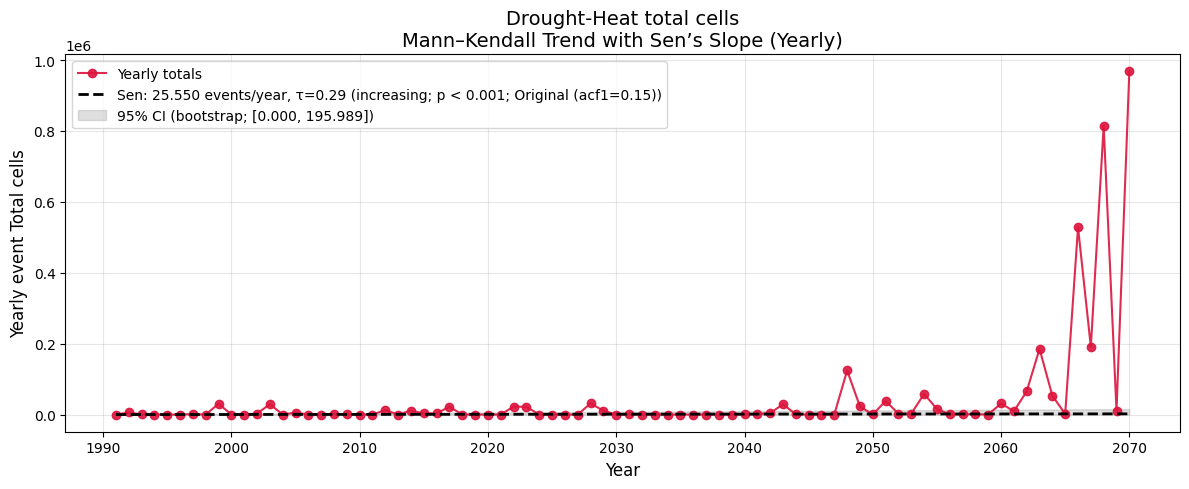


=== Drought-Heat total cells Yearly Trend Summary ===
MK method: Original (acf1=0.15)
Scale used for test: raw
Kendall’s tau (τ): 0.2946
Sen slope: 25.5500 events/year (increasing)
Bootstrap CI (slope): [0.0000, 195.9893]
Mann–Kendall: p < 0.001 (significance: ***)
CI excludes zero: True



In [20]:
dh_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','drought','temp','drought_heat',1991,2070,'Drought-Heat',color_choice='crimson')

In [ ]:
dw_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','drought','wind','drought_wind',1991,2070,'Drought-Wind',color_choice='gold')

In [ ]:
hw_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','temp','wind','heat_wind',1991,2070,'Heat-Wind',color_choice='orange')

In [ ]:
pd_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','prec','drought','prec_drought',1991,2070,'Prec-Drought',color_choice='forestgreen')

In [ ]:
ph_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','prec','temp','prec_heat',1991,2070,'Prec-Heat',color_choice='orchid')

In [ ]:
pw_85_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_85_full.csv','prec','wind','prec_wind',1991,2070,'Prec-Wind',color_choice='navy')

In [ ]:
pd.DataFrame([dh_85_output]).to_csv(
    "drought_heat_rcp85_mk_results.csv",
    index=False
)
pd.DataFrame([dw_85_output]).to_csv(
    "drought_wind_rcp85_mk_results.csv",
    index=False
)
pd.DataFrame([hw_85_output]).to_csv(
    "heat_wind_rcp85_mk_results.csv",
    index=False
)
pd.DataFrame([pd_85_output]).to_csv(
    "prec_drought_rcp85_mk_results.csv",
    index=False
)
pd.DataFrame([ph_85_output]).to_csv(
    "prec_heat_rcp85_mk_results.csv",
    index=False
)
pd.DataFrame([pw_85_output]).to_csv(
    "prec_wind_rcp85_mk_results.csv",
    index=False
)

In [ ]:
dh_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','drought','temp','drought_heat',1991,2070,'Drought-Heat',color_choice='crimson')

In [ ]:
dw_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','drought','wind','drought_wind',1991,2070,'Drought-Wind',color_choice='gold')

In [ ]:
hw_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','temp','wind','heat_wind',1991,2070,'Heat-Wind',color_choice='orange')

In [ ]:
pd_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','prec','drought','prec_drought',1991,2070,'Prec-Drought',color_choice='forestgreen')

In [ ]:
ph_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','prec','temp','prec_heat',1991,2070,'Prec-Heat',color_choice='orchid')

In [ ]:
pw_45_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_45_full.csv','prec','wind','prec_wind',1991,2070,'Prec-Wind',color_choice='navy')

In [ ]:
pd.DataFrame([dh_45_output]).to_csv(
    "drought_heat_rcp45_mk_results.csv",
    index=False
)
pd.DataFrame([dw_45_output]).to_csv(
    "drought_wind_rcp45_mk_results.csv",
    index=False
)
pd.DataFrame([hw_45_output]).to_csv(
    "heat_wind_rcp45_mk_results.csv",
    index=False
)
pd.DataFrame([pd_45_output]).to_csv(
    "prec_drought_rcp45_mk_results.csv",
    index=False
)
pd.DataFrame([ph_45_output]).to_csv(
    "prec_heat_rcp45_mk_results.csv",
    index=False
)
pd.DataFrame([pw_45_output]).to_csv(
    "prec_wind_rcp45_mk_results.csv",
    index=False
)

In [ ]:
dh_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','drought','temp','drought_heat',1991,2022,'Drought-Heat',color_choice='crimson')

In [ ]:
dw_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','drought','wind','drought_wind',1991,2022,'Drought-Wind',color_choice='gold')

In [ ]:
hw_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','temp','wind','heat_wind',1991,2022,'Heat-Wind',color_choice='orange')

In [ ]:
pd_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','prec','drought','prec_drought',1991,2022,'Prec-Drought',color_choice='forestgreen')

In [ ]:
ph_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','prec','temp','prec_heat',1991,2022,'Prec-Heat',color_choice='orchid')

In [ ]:
pw_rea_output=plot_mh_trends_mk_rao_bootstrap('consecutive_events_tl3_rea_veneto.csv','prec','wind','prec_wind',1991,2022,'Prec-Wind',color_choice='navy')

In [ ]:
pd.DataFrame([dh_rea_output]).to_csv(
    "drought_heat_rea_mk_results.csv",
    index=False
)
pd.DataFrame([dw_rea_output]).to_csv(
    "drought_wind_rea_mk_results.csv",
    index=False
)
pd.DataFrame([hw_rea_output]).to_csv(
    "heat_wind_rea_mk_results.csv",
    index=False
)
pd.DataFrame([pd_rea_output]).to_csv(
    "prec_drought_rea_mk_results.csv",
    index=False
)
pd.DataFrame([ph_rea_output]).to_csv(
    "prec_heat_rea_mk_results.csv",
    index=False
)
pd.DataFrame([pw_rea_output]).to_csv(
    "prec_wind_rea_mk_results.csv",
    index=False
)

In [ ]:
dh_rea=pd.read_csv('drought_heat_rea_mk_results.csv')
dh_45=pd.read_csv('drought_heat_rcp45_mk_results.csv')
dh_85=pd.read_csv('drought_heat_rcp85_mk_results.csv')

dw_rea=pd.read_csv('drought_wind_rea_mk_results.csv')
dw_45=pd.read_csv('drought_wind_rcp45_mk_results.csv')
dw_85=pd.read_csv('drought_wind_rcp85_mk_results.csv')

hw_rea=pd.read_csv('heat_wind_rea_mk_results.csv')
hw_45=pd.read_csv('heat_wind_rcp45_mk_results.csv')
hw_85=pd.read_csv('heat_wind_rcp85_mk_results.csv')

pd_rea=pd.read_csv('prec_drought_rea_mk_results.csv')
pd_45=pd.read_csv('prec_drought_rcp45_mk_results.csv')
pd_85=pd.read_csv('prec_drought_rcp85_mk_results.csv')

ph_rea=pd.read_csv('prec_heat_rea_mk_results.csv')
ph_45=pd.read_csv('prec_heat_rcp45_mk_results.csv')
ph_85=pd.read_csv('prec_heat_rcp85_mk_results.csv')

pw_rea=pd.read_csv('prec_wind_rea_mk_results.csv')
pw_45=pd.read_csv('prec_wind_rcp45_mk_results.csv')
pw_85=pd.read_csv('prec_wind_rcp85_mk_results.csv')

In [ ]:
dataset_table=pd.concat([dh_rea,dh_45,dh_85,dw_rea,dw_45,dw_85,hw_rea,hw_45,hw_85,pd_rea,pd_45,pd_85,ph_rea,ph_45,ph_85,pw_rea,pw_45,pw_85])
dataset_table.to_csv('trends_multi_hazard_pairs.csv',index=False)